<a href="https://colab.research.google.com/github/zaki43325010/JOBSHEET-AI-10/blob/main/JOBSHEET_AI_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAKTIKUM**

1. Percobaan 1: Implementasi Support Vector Machine (SVM)

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# --- SIMULASI DATASET DIABETES (TANPA CSV) ---
X_raw, y_raw = make_classification(
    n_samples=768, n_features=8, n_informative=6, n_redundant=2, random_state=42
)
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df = pd.DataFrame(X_raw, columns=feature_names)
df['Outcome'] = y_raw

# 1. Tampilkan 5 baris teratas & info dataset
print("=== 5 Baris Pertama ===")
print(df.head())
print("\n=== Informasi Dataset ===")
print(df.info())

# 2. Pemisahan Feature & Label
X = df[df.columns[:8]]
y = df['Outcome']

# 3. Scaling Data (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split Data Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.33, random_state=42
)

# 5. Training Model SVC Default
clf = SVC()
clf.fit(X_train, y_train)

# 6. Evaluasi Akurasi awal
print("\n=== HASIL PERCOBAAN 1 ===")
print("Akurasi Model SVC Base:", clf.score(X_test, y_test))

=== 5 Baris Pertama ===
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.070197  1.235046       2.165722       2.576582 -1.624230 -1.211503   
1     0.703291  1.049738       2.314180       0.307223 -2.066212 -1.962563   
2     1.452635  0.993905       2.590584       0.478721 -1.574429 -1.638273   
3     0.417141 -2.068016      -0.443590      -0.545615 -0.186952 -0.404071   
4    -1.588704  1.985772       2.335272       1.043653 -1.098579 -2.010187   

   DiabetesPedigreeFunction       Age  Outcome  
0                 -2.158989 -4.238967        1  
1                 -0.192410 -1.645851        1  
2                  0.727736 -1.263396        1  
3                 -0.129923  1.652275        1  
4                  1.618453  0.570588        1  

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                

2. Percobaan 2: Implementasi Support Vector Regression (SVR)

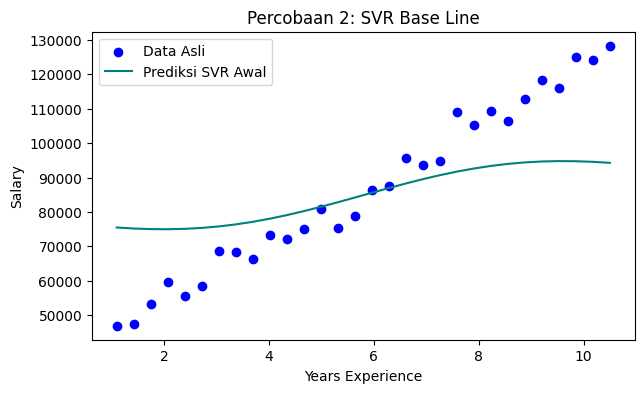

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# --- SIMULASI DATASET SALARY_DATA (TANPA CSV) ---
np.random.seed(42)
X_exp = np.linspace(1.1, 10.5, 30)
y_sal = 35000 + (X_exp * 9000) + np.random.normal(0, 4000, 30)

# Reshape X agar kompatibel dengan SKLearn
X = X_exp[:, np.newaxis]
y = y_sal

# Training SVR dengan parameter sesuai Jobsheet (C=1000, gamma=0.05, kernel='rbf')
model = SVR(C=1000, gamma=0.05, kernel='rbf')
model.fit(X, y)

# Visualisasi Hasil SVR Awal
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color='blue', label='Data Asli')
plt.plot(X, model.predict(X), color='teal', label='Prediksi SVR Awal')
plt.title('Percobaan 2: SVR Base Line')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

3. Percobaan 3: Implementasi Naïve Bayes

=== HASIL PERCOBAAN 3 ===
Akurasi Base Naïve Bayes: 98.75%
Confusion Matrix:
[[18  1]
 [ 0 61]]


/tmp/ipykernel_1028/1334140830.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


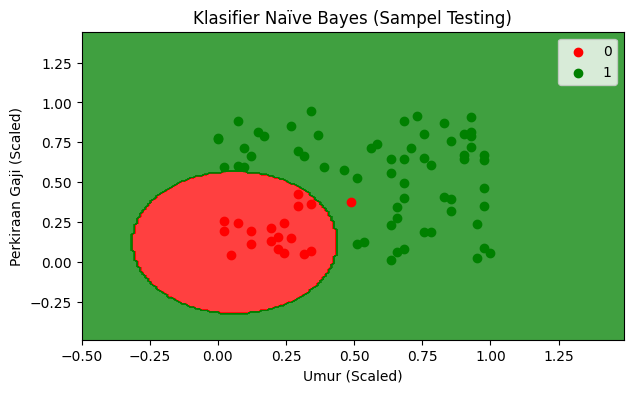

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# --- SIMULASI DATASET IKLAN SOSMED (TANPA CSV) ---
np.random.seed(99)
umur = np.random.randint(18, 60, 400)
gaji = np.random.randint(15000, 150000, 400)
transaksi = np.where((umur > 38) | (gaji > 90000), 1, 0)

X_raw = np.column_stack((umur, gaji))
y_raw = transaksi

# Split Data (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=99
)

# Convert ke NumPy Array
X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)

# Normalisasi MinMax
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Training Model GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Prediksi & Evaluasi Awal
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("=== HASIL PERCOBAAN 3 ===")
print("Akurasi Base Naïve Bayes: {:.2f}%".format(acc * 100))
print("Confusion Matrix:")
print(cm)

# Visualisasi Sample Data Test
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 0.5, stop=X_set[:, 0].max() + 0.5, step=0.01),
    np.arange(start=X_set[:, 1].min() - 0.5, stop=X_set[:, 1].max() + 0.5, step=0.01)
)
plt.figure(figsize=(7, 4))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Klasifier Naïve Bayes (Sampel Testing)')
plt.xlabel('Umur (Scaled)')
plt.ylabel('Perkiraan Gaji (Scaled)')
plt.legend()
plt.show()

# **TUGAS**

1. Tugas 1: Hyperparameter Tuning SVM & SVR (Grid Search)

=== HASIL TUNING TUGAS 1 (SVM) ===
Parameter Terbaik : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi Terbaik   : 99.06%

=== HASIL TUNING TUGAS 1 (SVR) ===
Parameter Terbaik : {'C': 1, 'gamma': 0.01, 'kernel': 'linear'}
R2 Score Terbaik  : 0.5157


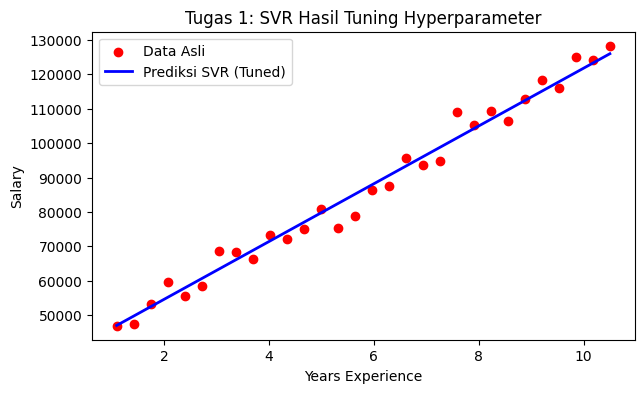

In [7]:
from sklearn.model_selection import GridSearchCV

# ==================== A. HYPERPARAMETER TUNING SVM ====================
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print("=== HASIL TUNING TUGAS 1 (SVM) ===")
print("Parameter Terbaik :", grid_svm.best_params_)
print("Akurasi Terbaik   : {:.2f}%".format(grid_svm.best_score_ * 100))


# ==================== B. HYPERPARAMETER TUNING SVR ====================
# Note: SVR sangat bergantung pada Feature Scaling untuk target y
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_svr_scaled = scaler_X.fit_transform(X)
y_svr_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

param_grid_svr = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.01, 0.1, 0.5, 'scale', 'auto'],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_svr_scaled, y_svr_scaled)

print("\n=== HASIL TUNING TUGAS 1 (SVR) ===")
print("Parameter Terbaik :", grid_svr.best_params_)
print("R2 Score Terbaik  : {:.4f}".format(grid_svr.best_score_))

# Visualisasi SVR Setelah Tuning
best_svr = grid_svr.best_estimator_
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color='red', label='Data Asli')
plt.plot(X, scaler_y.inverse_transform(best_svr.predict(X_svr_scaled).reshape(-1, 1)),
         color='blue', linewidth=2, label='Prediksi SVR (Tuned)')
plt.title('Tugas 1: SVR Hasil Tuning Hyperparameter')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

2. Tugas 2: Hyperparameter Tuning Naïve Bayes

In [8]:
# Tuning parameter var_smoothing pada GaussianNB
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=10, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
y_pred_tuned = best_nb.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("=== HASIL TUNING TUGAS 2 (NAÏVE BAYES) ===")
print("Parameter var_smoothing Terbaik :", grid_nb.best_params_['var_smoothing'])
print("Akurasi Awal (Percobaan 3)      : {:.2f}%".format(acc * 100))
print("Akurasi Setelah Tuning (Tugas 2): {:.2f}%".format(acc_tuned * 100))

=== HASIL TUNING TUGAS 2 (NAÏVE BAYES) ===
Parameter var_smoothing Terbaik : 0.08111308307896872
Akurasi Awal (Percobaan 3)      : 98.75%
Akurasi Setelah Tuning (Tugas 2): 98.75%
